# Some title

## Sources:
- [Website title](www.some_website.com)

## Import modules

In [2]:
# import internal modules
# from typing import List, Set, Dict, TypedDict, Tuple, Optional, Union
from pathlib import Path

# import 3rd-party modules
import numpy as np
import cv2
import mediapipe as mp

# import local modules


objc[12040]: Class CaptureDelegate is implemented in both /Users/derrickvanfrausum/anaconda3/envs/cv/lib/python3.9/site-packages/cv2/cv2.abi3.so (0x16050e538) and /Users/derrickvanfrausum/anaconda3/envs/cv/lib/python3.9/site-packages/mediapipe/.dylibs/libopencv_videoio.3.4.16.dylib (0x12f440860). One of the two will be used. Which one is undefined.
objc[12040]: Class CVWindow is implemented in both /Users/derrickvanfrausum/anaconda3/envs/cv/lib/python3.9/site-packages/cv2/cv2.abi3.so (0x16050e588) and /Users/derrickvanfrausum/anaconda3/envs/cv/lib/python3.9/site-packages/mediapipe/.dylibs/libopencv_highgui.3.4.16.dylib (0x10e3c4a68). One of the two will be used. Which one is undefined.
objc[12040]: Class CVView is implemented in both /Users/derrickvanfrausum/anaconda3/envs/cv/lib/python3.9/site-packages/cv2/cv2.abi3.so (0x16050e5b0) and /Users/derrickvanfrausum/anaconda3/envs/cv/lib/python3.9/site-packages/mediapipe/.dylibs/libopencv_highgui.3.4.16.dylib (0x10e3c4a90). One of the two w

## Define CONSTANTS & variables

In [3]:
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles
mp_holistic = mp.solutions.holistic
# mp_face_mesh = mp.solutions.face_mesh

## Define functions

## Run logic

In [4]:
# set video path
video_path = Path("/Users/derrickvanfrausum/BeCode_AI/git-repos/sports-vision/object_detection/data/video_inputs/federer-slow-motion-backhand-trim.mp4")
# video_path = 1 # webcam number

In [6]:
video_cap = cv2.VideoCapture(str(video_path))

# set empty list to store xyz landmarks
landmarks_xyzs = []

with mp_holistic.Holistic(
  min_detection_confidence=0.7,
  min_tracking_confidence=0.7) as holistic:

  while video_cap.isOpened():
    success, image = video_cap.read()
    if not success:
      print("Ignoring empty camera frame.")
      # If loading a video, use 'break' instead of 'continue'.
      if isinstance(video_path, int):
        continue
      else:
        break

    # To improve performance, optionally mark the image as not writeable to
    # pass by reference.
    image.flags.writeable = False
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = holistic.process(image)

    # Draw landmark annotation on the image.
    image.flags.writeable = True
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    mp_drawing.draw_landmarks(
        image,
        results.face_landmarks,
        mp_holistic.FACEMESH_CONTOURS,
        landmark_drawing_spec=None,
        connection_drawing_spec=mp_drawing_styles
        .get_default_face_mesh_contours_style())
    mp_drawing.draw_landmarks(
        image,
        results.pose_landmarks,
        mp_holistic.POSE_CONNECTIONS,
        landmark_drawing_spec=mp_drawing_styles
        .get_default_pose_landmarks_style())

    # Flip the image horizontally for a selfie-view display.
    cv2.imshow('MediaPipe Holistic', cv2.flip(image, 1))
    if cv2.waitKey(5) & 0xFF == 27:
      break

    landmarks_xyzs.append([(landmark.x, landmark.y, landmark.z) for landmark in results.pose_landmarks.landmark])

video_cap.release()

cv2.destroyAllWindows()
cv2.waitKey(1)

Ignoring empty camera frame.


-1

## Save landmarks

In [7]:
# convert list to numpy array
landmarks_xyzs_array = np.array(landmarks_xyzs)

# set landmarks array path
landmarks_xyzs_array_path = video_path.parent / f"{video_path.stem}.npy"
print(landmarks_xyzs_array_path)

# save landmarks array
np.save(landmarks_xyzs_array_path, landmarks_xyzs_array)

/Users/derrickvanfrausum/BeCode_AI/git-repos/sports-vision/object_detection/data/video_inputs/federer-slow-motion-backhand-trim.npy


In [9]:
landmarks_xyzs_array.shape

(247, 33, 3)

In [22]:
nb_frames = landmarks_xyzs_array.shape[0]

In [24]:
np.arange(0, nb_frames, step=100)

array([  0, 100, 200])

In [26]:
import matplotlib.pyplot as plt
y = landmarks_xyzs_array[:,29,0]

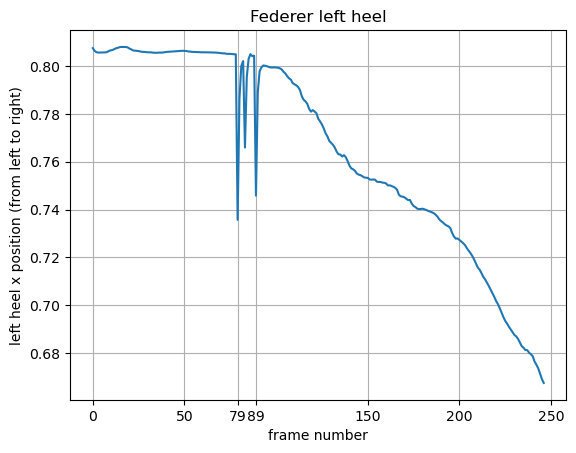

In [25]:
extraticks = [0, 50, 79, 89, 150, 200, 250]

plt.title("Federer left heel")
plt.xlabel("frame number")
plt.ylabel("left heel x position (from left to right)")
plt.plot(landmarks_xyzs_array[:,29,0])

# plt.xticks(list(plt.xticks()[0]) + extraticks)
plt.xticks(extraticks)

plt.grid()

plt.show()
plt.show()

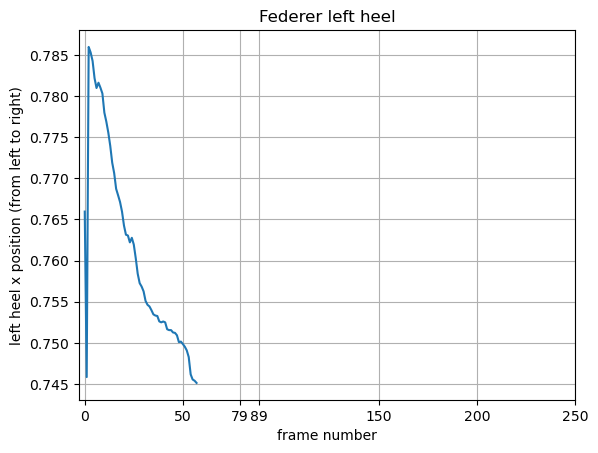

In [39]:
def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    y_smooth = np.convolve(y, box, mode='same')
    return y_smooth

def remove_outliers(data, m=2):
    data = np.array(data)
    mean = np.mean(data)
    std = np.std(data)
    filtered_data = data[abs(data - mean) <= m * std]
    return filtered_data

y_smooth = smooth(y, 20)
y_filtered = remove_outliers(y, m=0.5)



plt.title("Federer left heel")
plt.xlabel("frame number")
plt.ylabel("left heel x position (from left to right)")
# plt.plot(y_smooth)
plt.plot(y_filtered)

# plt.xticks(list(plt.xticks()[0]) + extraticks)
plt.xticks(extraticks)

plt.grid()

plt.show()

In [40]:
def detect_peaks(data, lookahead=500, threshold=0.05):
    """
    Detect peaks in time series data using a simple algorithm.
    :param data: Time series data (numpy array)
    :param lookahead: Number of data points to consider before and after a peak
    :param threshold: Minimum relative amplitude of a peak to be considered a peak
    :return: List of indices of detected peaks
    """
    peaks = []
    for i in range(len(data)):
        if i < lookahead:
            continue
        elif i > len(data) - lookahead:
            break
        elif data[i] > threshold * np.max(data):
            peaks.append(i)
    return peaks

In [47]:
peaks = detect_peaks(y, lookahead=20, threshold=0.02)
print(peaks)

[20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227]


In [57]:
import numpy as np

def detect_peaks_and_troughs(data, lookahead=500, threshold=0.05):
    """
    Detect peaks and troughs in time series data using a simple algorithm.
    :param data: Time series data (numpy array)
    :param lookahead: Number of data points to consider before and after a peak or trough
    :param threshold: Minimum relative amplitude of a peak or trough to be considered a peak or trough
    :return: Tuple of lists of indices of detected peaks and troughs
    """
    peaks = []
    troughs = []
    for i in range(len(data)):
        if i < lookahead:
            continue
        elif i > len(data) - lookahead:
            break
        elif data[i] > threshold * np.max(data):
            peaks.append(i)
        elif data[i] < threshold * np.min(data):
            troughs.append(i)
    return peaks, troughs

peaks, troughs = detect_peaks_and_troughs(y[70:100], lookahead=10, threshold=0.1)
print(peaks)
print(troughs)



[10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]
[]


In [ ]:
plt.title("Federer left heel")
plt.xlabel("frame number")
plt.ylabel("left heel x position (from left to right)")
# plt.plot(y_smooth)
plt.plot(y_filtered)

# plt.xticks(list(plt.xticks()[0]) + extraticks)
plt.xticks(extraticks)

plt.grid()

plt.show()

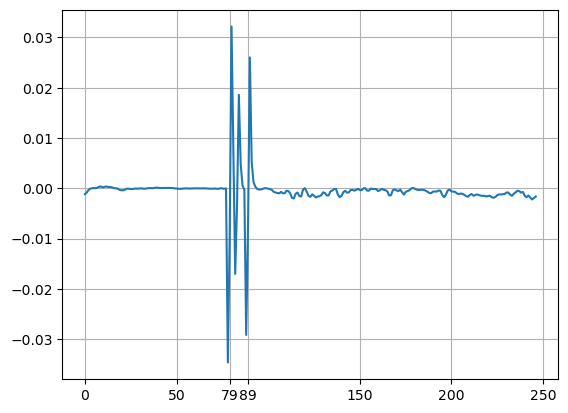

In [64]:

plt.plot(np.gradient(y))

# plt.xticks(list(plt.xticks()[0]) + extraticks)
plt.xticks(extraticks)

plt.grid()

plt.show()

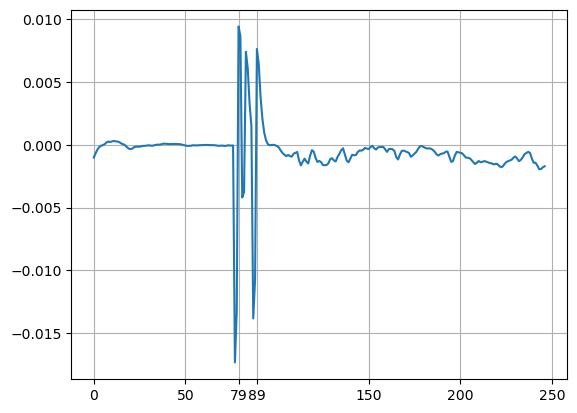

In [67]:
def interpolate_outliers(data, m=2):
    data = np.array(data)
    mean = np.mean(data)
    std = np.std(data)
    outliers = data[abs(data - mean) > m * std]
    for outlier in outliers:
        index = np.where(data == outlier)[0][0]
        if index == 0:
            data[index] = (data[index+1] + data[index]) / 2
        elif index == len(data) - 1:
            data[index] = (data[index-1] + data[index]) / 2
        else:
            data[index] = (data[index-1] + data[index+1]) / 2
    return data


interpolated_data = interpolate_outliers(np.gradient(y), 0.005)

plt.plot(interpolated_data)

# plt.xticks(list(plt.xticks()[0]) + extraticks)
plt.xticks(extraticks)

plt.grid()

plt.show()

In [68]:
def remove_outliers(data, m=2):
    data = np.array(data)
    mean = np.mean(data)
    std = np.std(data)
    filtered_data = data[abs(data - mean) <= m * std]
    return filtered_data

In [72]:
np.std(np.gradient(y))

0.004389859306387543

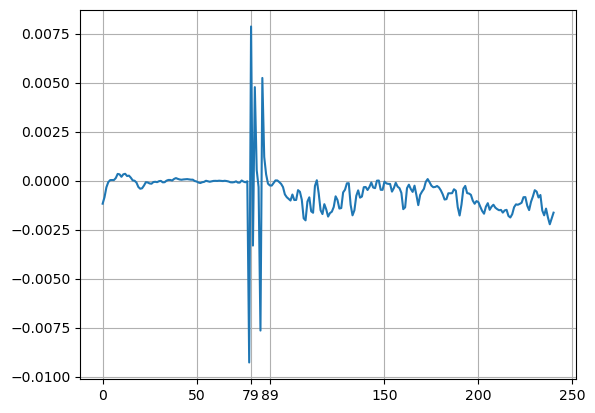

In [76]:
filtered_data = remove_outliers(np.gradient(y), )

plt.plot(filtered_data)

# plt.xticks(list(plt.xticks()[0]) + extraticks)
plt.xticks(extraticks)

plt.grid()

plt.show()

In [11]:
landmarks_xyzs_array[:,29,0]

array([0.80755627, 0.80637681, 0.80586451, 0.80568981, 0.8057043 ,
       0.80573571, 0.80575973, 0.80578625, 0.80601931, 0.8064667 ,
       0.80665457, 0.80684948, 0.80729151, 0.80754077, 0.80775577,
       0.80804598, 0.80804932, 0.80806607, 0.80803168, 0.80786312,
       0.80737829, 0.8070299 , 0.80659086, 0.80651963, 0.80642641,
       0.80632657, 0.80613297, 0.80600387, 0.80598164, 0.80587894,
       0.80582106, 0.80581462, 0.80578864, 0.80563307, 0.80562365,
       0.80562365, 0.80568635, 0.80568492, 0.80569488, 0.8058483 ,
       0.80594873, 0.80602235, 0.80606067, 0.80610734, 0.80617762,
       0.8062399 , 0.80632746, 0.80636597, 0.80642033, 0.80645692,
       0.8063755 , 0.80636472, 0.80617505, 0.80611658, 0.80600482,
       0.80598593, 0.80598509, 0.80591106, 0.80586469, 0.80583459,
       0.80582917, 0.80580676, 0.80579054, 0.80579394, 0.8057543 ,
       0.80574405, 0.80573398, 0.80569518, 0.80564022, 0.80552405,
       0.8054539 , 0.8053633 , 0.80537432, 0.80515736, 0.80516

## Reduce jittering of pose estimation

Chatgpt:
To reduce jittering in mediapipe pose landmarks, you can use a smoothing technique such as exponential smoothing. Exponential smoothing works by applying a smoothing factor to the current value and the previous smoothed value, so that the output value is a weighted average of the current value and the previous smoothed value.

Here is an example of how you can implement exponential smoothing in Python:



In [ ]:
def exponential_smoothing(alpha, data):
    smoothed_data = []
    for i in range(len(data)):
        if i == 0:
            smoothed_data.append(data[i])
        else:
            smoothed_data.append(alpha * data[i] + (1 - alpha) * smoothed_data[i-1])
    return smoothed_data

# Example usage
alpha = 0.5  # Smoothing factor
data = [1, 2, 3, 4, 5, 6]
smoothed_data = exponential_smoothing(alpha, data)
print(smoothed_data)  # Output: [1, 1.5, 2.25, 3.125, 4.0625, 5.03125]


In this example, the alpha parameter determines the amount of smoothing applied. A larger value of alpha will result in more smoothing, while a smaller value will result in less smoothing.

You can adjust the value of alpha to find the best balance between smoothing and preserving the original signal. You can also experiment with different smoothing techniques, such as moving average or low pass filtering, to see which one works best for your specific application.

To implement a low pass filter in Python, you can use a simple moving average. A moving average works by taking the average of a set of consecutive data points and using that average as the output value. This has the effect of smoothing the data and removing high frequency noise.

Here is an example of how you can implement a moving average low pass filter in Python:

In [10]:
def low_pass_filter(data, window_size):
    filtered_data = []
    for i in range(len(data)):
        if i < window_size:
            filtered_data.append(sum(data[:i+1]) / (i+1))
        else:
            filtered_data.append(sum(data[i-window_size+1:i+1]) / window_size)
    return filtered_data

# Example usage
data = [1, 2, 3, 4, 5, 6]
window_size = 3  # Size of the moving average window
filtered_data = low_pass_filter(data, window_size)
print(filtered_data)  # Output: [1, 1.5, 2.0, 3.0, 4.0, 5.0]


[1.0, 1.5, 2.0, 3.0, 4.0, 5.0]


In [17]:
landmarks_xyzs_array.shape

(752, 33, 3)

In [24]:
smooth_landmarks_xyzs_array = np.empty_like(landmarks_xyzs_array)

for axis in range(landmarks_xyzs_array.shape[2]):
    for landmark_idx in range(landmarks_xyzs_array.shape[1]):
        smooth_landmarks_xyzs_array[:,landmark_idx,axis] = low_pass_filter(landmarks_xyzs_array[:,landmark_idx,axis], 3)

In [33]:
landmarks_xyzs_array[:3,0,:], smooth_landmarks_xyzs_array[:3,0,:]

(array([[0.48658189, 0.32495433, 0.3020542 ],
        [0.48658976, 0.32526022, 0.23267092],
        [0.48657185, 0.32534787, 0.22369838]]),
 array([[0.48658189, 0.32495433, 0.3020542 ],
        [0.48658583, 0.32510728, 0.26736256],
        [0.48658117, 0.32518747, 0.25280783]]))

In this example, the window_size parameter determines the number of data points to include in the moving average. A larger window size will result in more smoothing, while a smaller window size will preserve more of the original signal.

You can adjust the value of window_size to find the best balance between smoothing and preserving the original signal. You can also experiment with different window sizes to see which one works best for your specific application.

In [9]:
# Example usage
data = [1, 2, 3, 4, 5, 6]
window_size = 3  # Size of the moving average window

filtered_data = []
for i in range(len(data)):
    print(i)
    if i < window_size:
        print(data[:i+1], (i+1))
        filtered_data.append(sum(data[:i+1]) / (i+1))
    else:
        print(data[i-window_size+1:i+1], window_size)
        filtered_data.append(sum(data[i-window_size+1:i+1]) / window_size)

    print(filtered_data)


0
[1] 1
[1.0]
1
[1, 2] 2
[1.0, 1.5]
2
[1, 2, 3] 3
[1.0, 1.5, 2.0]
3
[2, 3, 4] 3
[1.0, 1.5, 2.0, 3.0]
4
[3, 4, 5] 3
[1.0, 1.5, 2.0, 3.0, 4.0]
5
[4, 5, 6] 3
[1.0, 1.5, 2.0, 3.0, 4.0, 5.0]


To filter out outliers in mediapipe pose landmarks, you can use a technique called statistical outlier removal. This involves identifying points that are significantly different from the rest of the data and removing them.

Here is an example of how you can implement statistical outlier removal in Python:

In [ ]:
import numpy as np

def remove_outliers(data, m=2):
    data = np.array(data)
    mean = np.mean(data)
    std = np.std(data)
    filtered_data = data[abs(data - mean) <= m * std]
    return filtered_data

# Example usage
data = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
filtered_data = remove_outliers(data)
print(filtered_data)  # Output: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In this example, the m parameter determines the number of standard deviations away from the mean that a point must be to be considered an outlier. A larger value of m will result in more points being removed, while a smaller value will result in fewer points being removed.

You can adjust the value of m to find the best balance between removing outliers and preserving the original data. You can also experiment with different outlier removal techniques, such as the interquartile range method, to see which one works best for your specific application.

To replace outliers in mediapipe pose landmarks with interpolated data, you can use a technique called linear interpolation. Linear interpolation works by fitting a straight line between two known points and using that line to estimate the value at any other point within the range of those two points.

Here is an example of how you can implement linear interpolation in Python:

In [ ]:
import numpy as np

def interpolate_outliers(data, m=2):
    data = np.array(data)
    mean = np.mean(data)
    std = np.std(data)
    outliers = data[abs(data - mean) > m * std]
    for outlier in outliers:
        index = np.where(data == outlier)[0][0]
        if index == 0:
            data[index] = (data[index+1] + data[index]) / 2
        elif index == len(data) - 1:
            data[index] = (data[index-1] + data[index]) / 2
        else:
            data[index] = (data[index-1] + data[index+1]) / 2
    return data

# Example usage
data = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
interpolated_data = interpolate_outliers(data)
print(interpolated_data)  # Output: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In this example, the m parameter determines the number of standard deviations away from the mean that a point must be to be considered an outlier. A larger value of m will result in more points being replaced, while a smaller value will result in fewer points being replaced.

You can adjust the value of m to find the best balance between replacing outliers and preserving the original data. You can also experiment with different interpolation methods, such as polynomial interpolation or spline interpolation, to see which one works best for your specific application.

In [14]:
def draw_keypoints(keypoints_xs, keypoints_ys, keypoints_connections,
                        image_height, image_width, image=None,
                        dot_color_bgr=(255,0,0), line_color_bgr=(0,0,255),
                        circle_radius = 5, line_thickness = 1
                    ) -> np.array:
    """
    Function to draw pose keypoints and connections between them.
    
    Retuns: image with keypoints and connections drawn
    """
    
    # loop through all keypoints
    for idx in range(len(keypoints_xs)):
        
        # get xy coords
        xy = (keypoints_xs[idx], keypoints_ys[idx])
        
        # draw circles
        cv2.circle(image,
                tuple(np.multiply(xy, (image_width, image_height)).astype(int)), # center coordinates
                circle_radius, # radius of circle
                dot_color_bgr, # color in bgr
                line_thickness # line thickness
                )

    # loop through all keypoints connections
    for start_kp_idx, end_kp_idx in keypoints_connections:
        
        # get xy coords of line start and end
        start_line = (keypoints_xs[start_kp_idx], keypoints_ys[start_kp_idx])
        end_line = (keypoints_xs[end_kp_idx], keypoints_ys[end_kp_idx])
        
        # draw line
        cv2.line(image,
                tuple(np.multiply(start_line, (image_width, image_height)).astype(int)),
                tuple(np.multiply(end_line, (image_width, image_height)).astype(int)),
                line_color_bgr, # color in bgr
                line_thickness # line thickness
                )
    
    return image

In [8]:
# set landmarks array path
landmarks_xyzs_array_path = video_path.parent / f"{video_path.stem}.npy"

# save landmarks array
landmarks_xyzs_array = np.load(landmarks_xyzs_array_path)

In [11]:
smooth_landmarks_xyzs_array = np.empty_like(landmarks_xyzs_array)

for axis in range(landmarks_xyzs_array.shape[2]):
    for landmark_idx in range(landmarks_xyzs_array.shape[1]):
        smooth_landmarks_xyzs_array[:,landmark_idx,axis] = low_pass_filter(landmarks_xyzs_array[:,landmark_idx,axis], 3)

In [18]:
from imutils.video import FileVideoStream
from imutils.video import FPS
import time

In [19]:
WINDOW_NAME = "frame" # set window name
QUEUE_SIZE = 128 # set queue size (i.e. buffer)

# set output video codec
# use avc1 instead of h264 for mp4 video as tag 0x34363268/'h264' is not supported with codec and mp4 format
CODEC = "avc1"

In [23]:
# set input & output video path
video_path = Path("/Users/derrickvanfrausum/BeCode_AI/git-repos/coding-art/core/assets/images/gagu/classic.mp4")
out_path = f"{video_path.parent}/{video_path.stem}_processed.mp4"

# initialize video stream
# pass transform fct to process frame in file video stream thread
fvs = FileVideoStream(path=str(video_path), transform=None, queue_size=QUEUE_SIZE)

# get video stream parameters
video_n_frames = int(fvs.stream.get(cv2.CAP_PROP_FRAME_COUNT))
video_fps = fvs.stream.get(cv2.CAP_PROP_FPS)
video_width = int(fvs.stream.get(cv2.CAP_PROP_FRAME_WIDTH))
video_height = int(fvs.stream.get(cv2.CAP_PROP_FRAME_HEIGHT))
frame_nb = int(fvs.stream.get(cv2.CAP_PROP_POS_FRAMES))

print(f"number of frames = {video_n_frames}")
print(f"fps = {video_fps}")
print(f"video width = {video_width}")
print(f"video height = {video_height}")

# create a videoWriter object
fourcc = cv2.VideoWriter_fourcc(*CODEC)
out_video = cv2.VideoWriter(filename=out_path, fourcc=fourcc, fps=video_fps, frameSize=(video_width, video_height))

# start file video stream thread and allow buffer to
# start to fill
print("[INFO] starting video file thread...")
fvs.start()
time.sleep(1.0)

# start fps timer to monitor runtime
fps = FPS().start()

# loop over frames from video file stream
while fvs.more():

	# grab frame from the threaded video file stream
	frame = fvs.read()
	if frame is None:
		print("Ignoring empty camera frame.")
		break

	# process frame
	frame = draw_keypoints(
        smooth_landmarks_xyzs_array[frame_nb,:,0],
        smooth_landmarks_xyzs_array[frame_nb,:,1],
        mp_holistic.POSE_CONNECTIONS,
        video_height, video_width, 
        frame,
        dot_color_bgr=tuple(np.random.randint(0,255,size=3).tolist()),
        line_color_bgr=tuple(np.random.randint(0,255,size=3).tolist())
        )

	# show frame
	cv2.imshow(WINDOW_NAME, frame)

    # wait for a key 
    # 0xFF to check what key we pressed on the keyboard
	key = cv2.waitKey(10) & 0xFF

    # break out of stream loop if esc or 'q' is pressed
	if key == 27 or key == ord('q'):        
		break
	
	# write output frame
	out_video.write(frame)

	# update fps counter
	fps.update()

	frame_nb += 1
	
# stop timer and display FPS information
fps.stop()
print("[INFO] elasped time: {:.2f}".format(fps.elapsed()))
print("[INFO] approx. FPS: {:.2f}".format(fps.fps()))

# close windows
cv2.destroyAllWindows()
cv2.waitKey(1) # workaround to effectively close window on mac

# release video stream & video rendering
fvs.stop()
out_video.release()

number of frames = 752
fps = 30.02294306464692
video width = 720
video height = 1280
[INFO] starting video file thread...
Ignoring empty camera frame.
[INFO] elasped time: 13.15
[INFO] approx. FPS: 57.18


: 